experiment_path: /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/experiment_test.csv
selected_graphs_path: /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/training_selected_graphs.csv
num experiment rows: 216
num selected graphs: 3
runs that exist on disk: 216
Runs with local.csv parsed: 216

TopK configs per graph (aggregated over seeds):


,graph_id,n_seeds,val_loss_mean,gap_mean,auprc_mean,f1_mean,stopped_epoch_mean,mcw_norm,num_layers,lr,weight_decay,dropout,hidden_dim
11,108,3,0.367436,0.200703,0.919749,0.863495,77.000000,auto,6,0.0010,0.0000,0.1,64
14,108,3,0.376993,0.112238,0.918749,0.857753,92.333333,auto,6,0.0010,0.0001,0.1,32
15,108,3,0.378307,0.156948,0.921084,0.860763,71.666667,auto,6,0.0010,0.0001,0.1,64
10,108,3,0.383098,0.055018,0.917040,0.854615,70.000000,auto,6,0.0010,0.0000,0.1,32
35,623,3,0.440315,0.137184,0.825749,0.777696,54.666667,auto,6,0.0010,0.0000,0.1,64
39,623,3,0.456162,0.144055,0.827461,0.780892,56.000000,auto,6,0.0010,0.0001,0.1,64
38,623,3,0.475518,0.129314,0.825065,0.775934,85.000000,auto,6,0.0010,0.0001,0.1,32
27,623,3,0.479256,0.129985,0.819643,0.773892,68.333333,auto,6,0.0005,0.0000,0.1,64
59,751,3,0.471101,0.039174,0.844073,0.791547,44.333333,auto,6,0.0010,0.0000,0.1,64
63,751,3,0.484792,0.035788,0.843812,0.791027,44.666667,auto,6,0.0010,0.0001,0.1,64



graph_id: 751
Top configs:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0 | do=0.1 | hd=64
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64
 - mcw=auto | L=6 | lr=0.001 | wd=0.0 | do=0.1 | hd=32
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.0 | hd=64


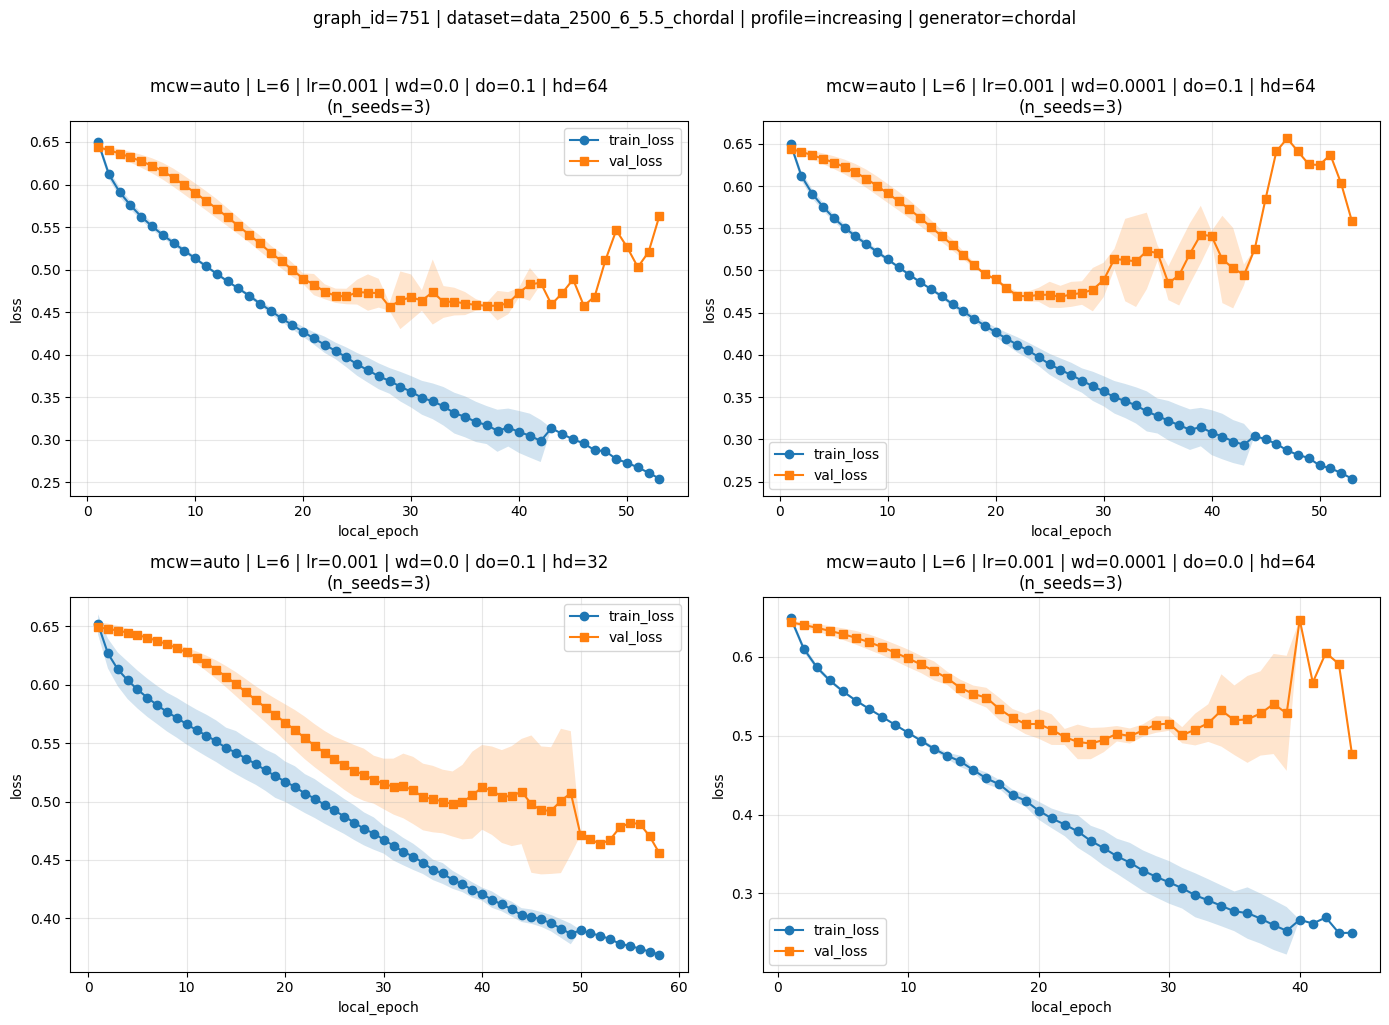

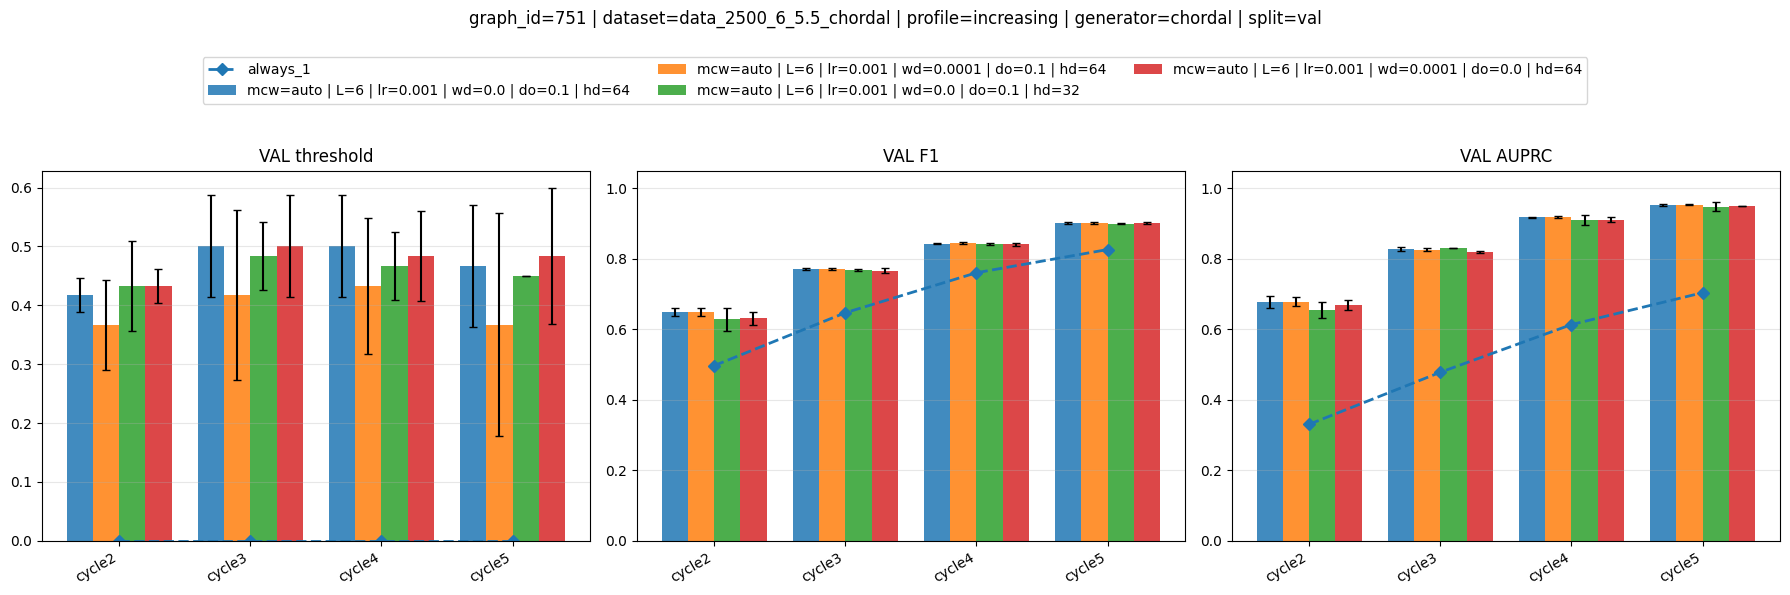

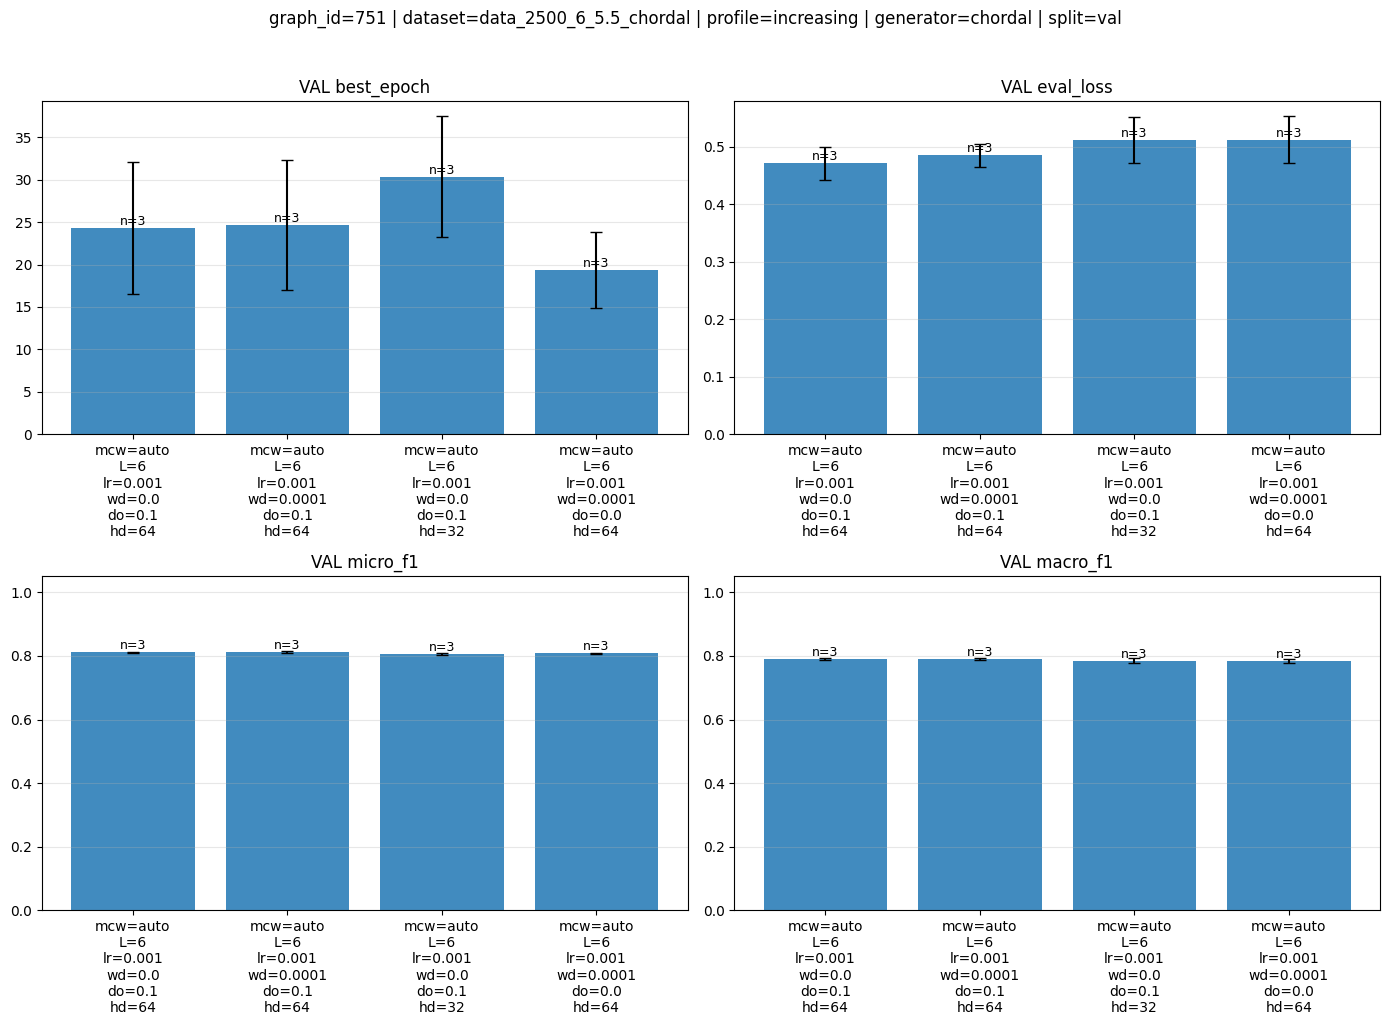

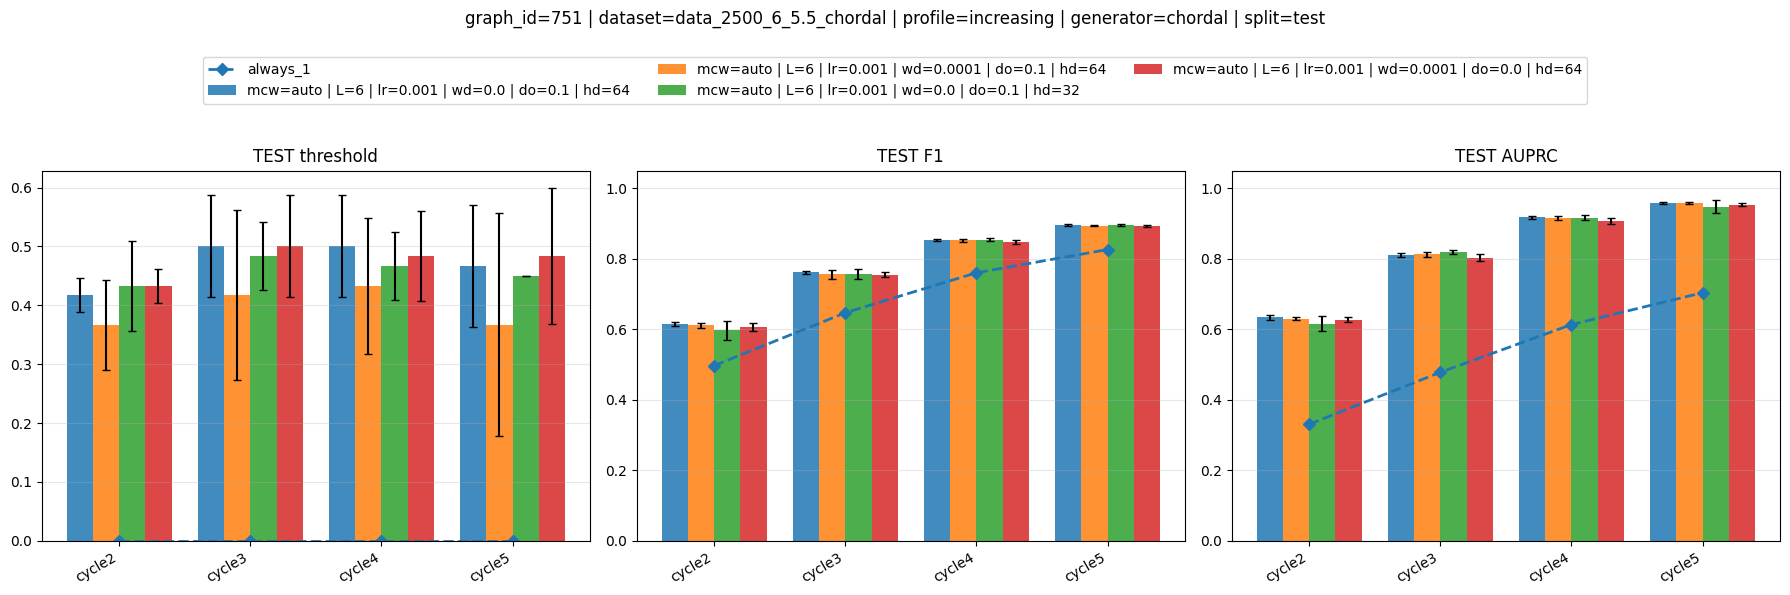

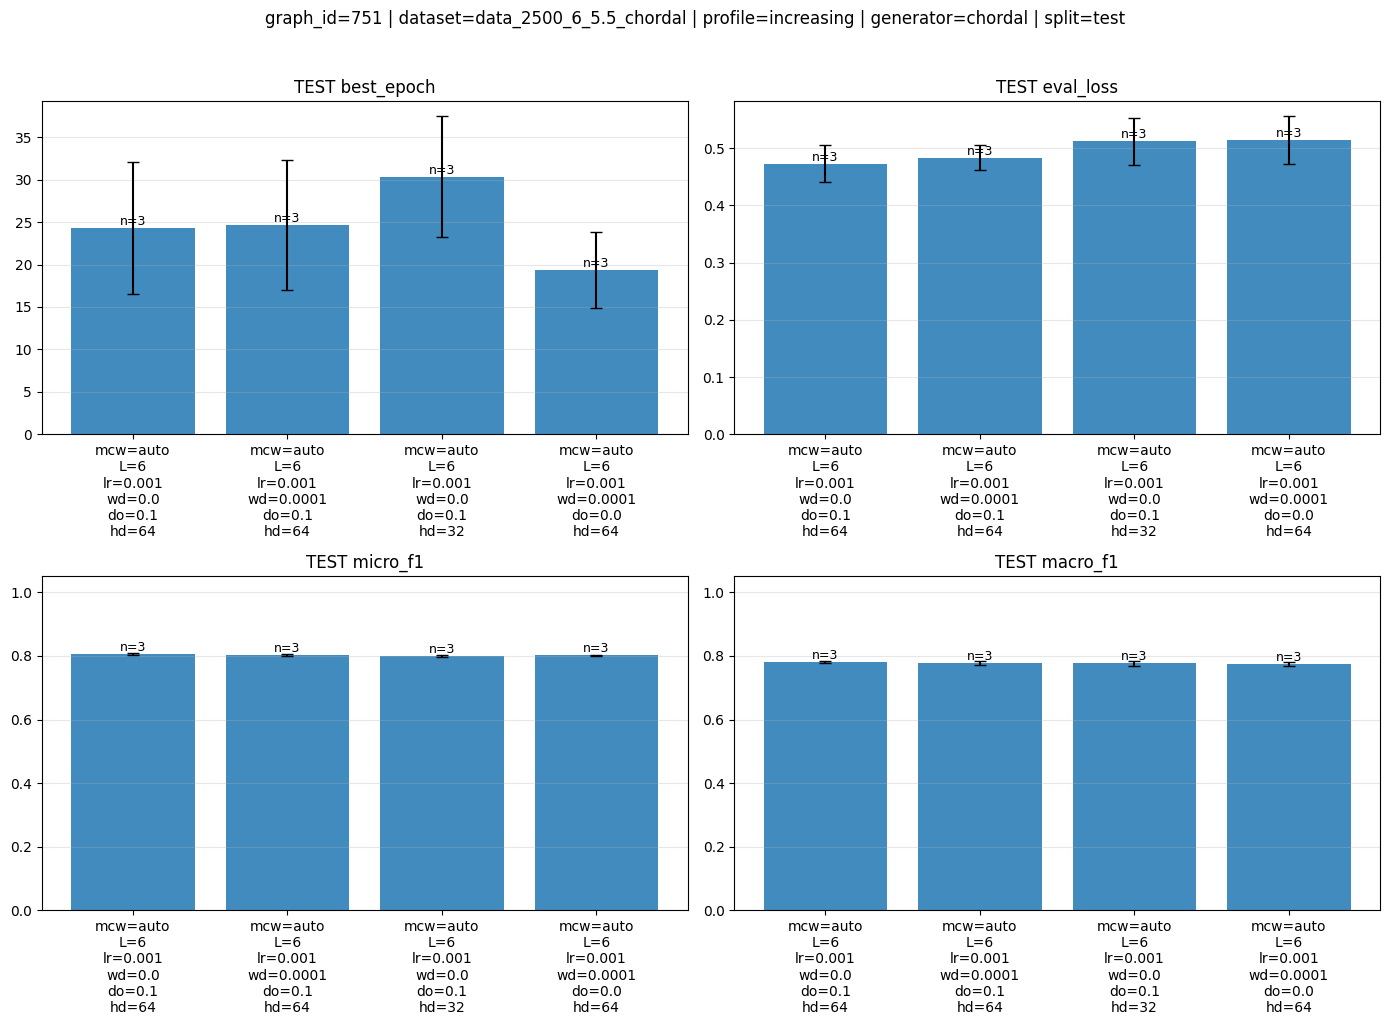


graph_id: 108
Top configs:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0 | do=0.1 | hd=64
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=32
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64
 - mcw=auto | L=6 | lr=0.001 | wd=0.0 | do=0.1 | hd=32


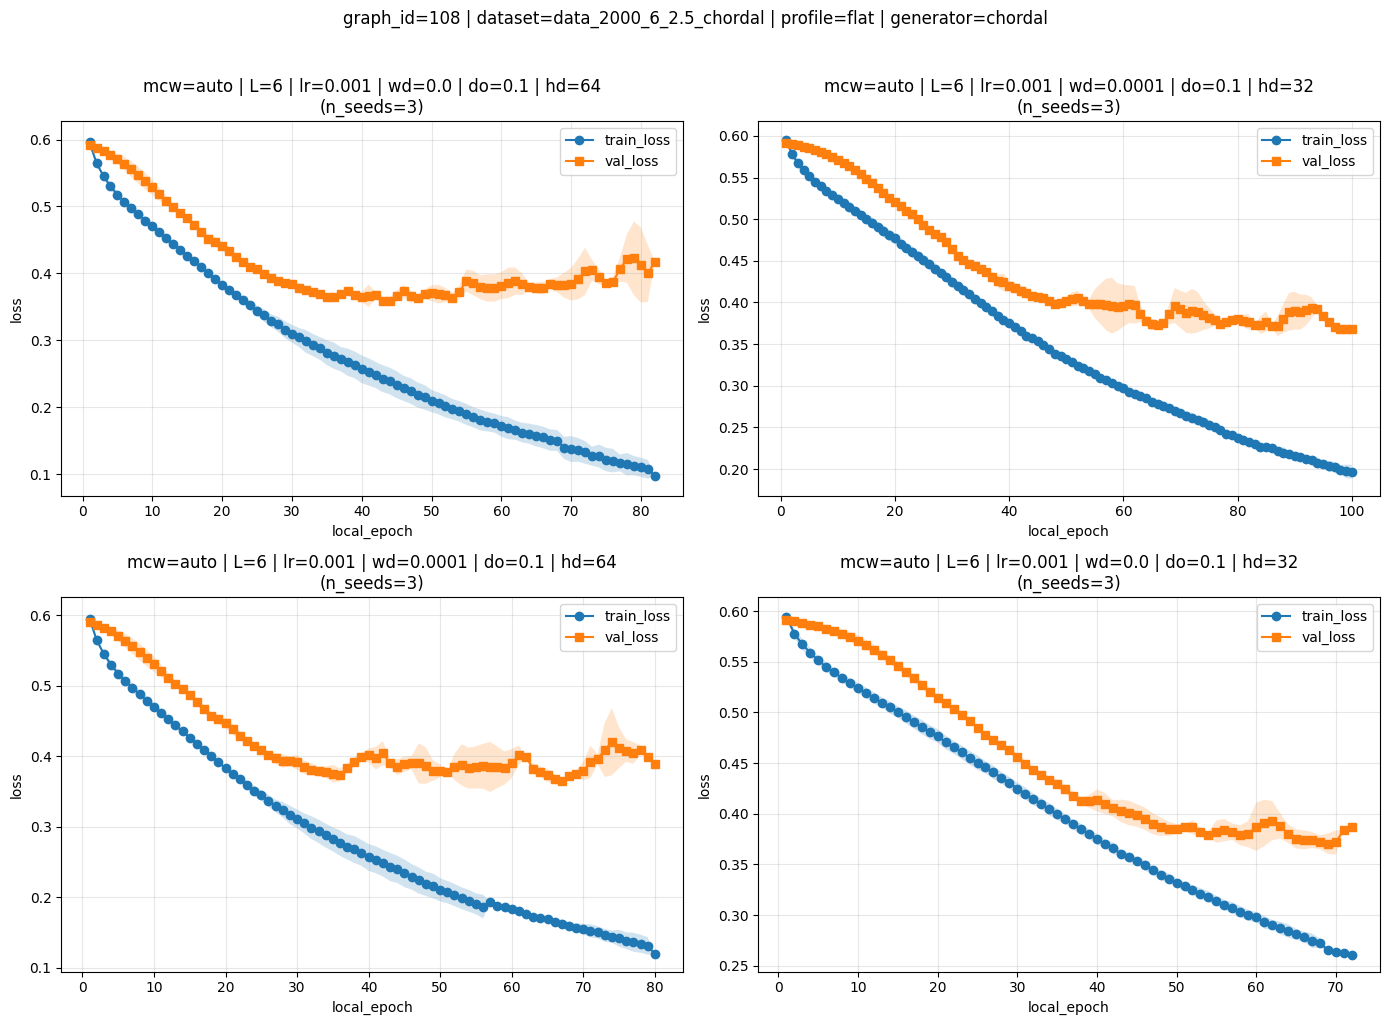

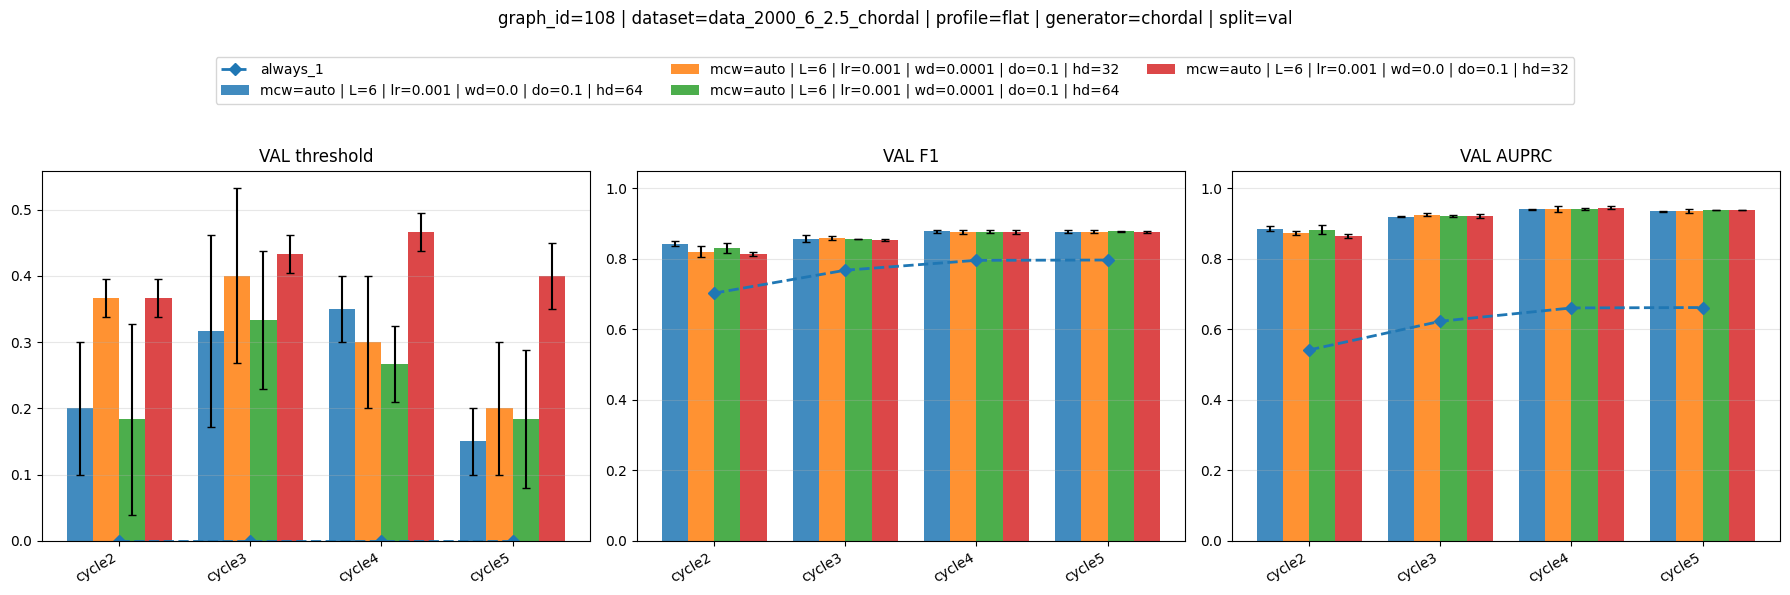

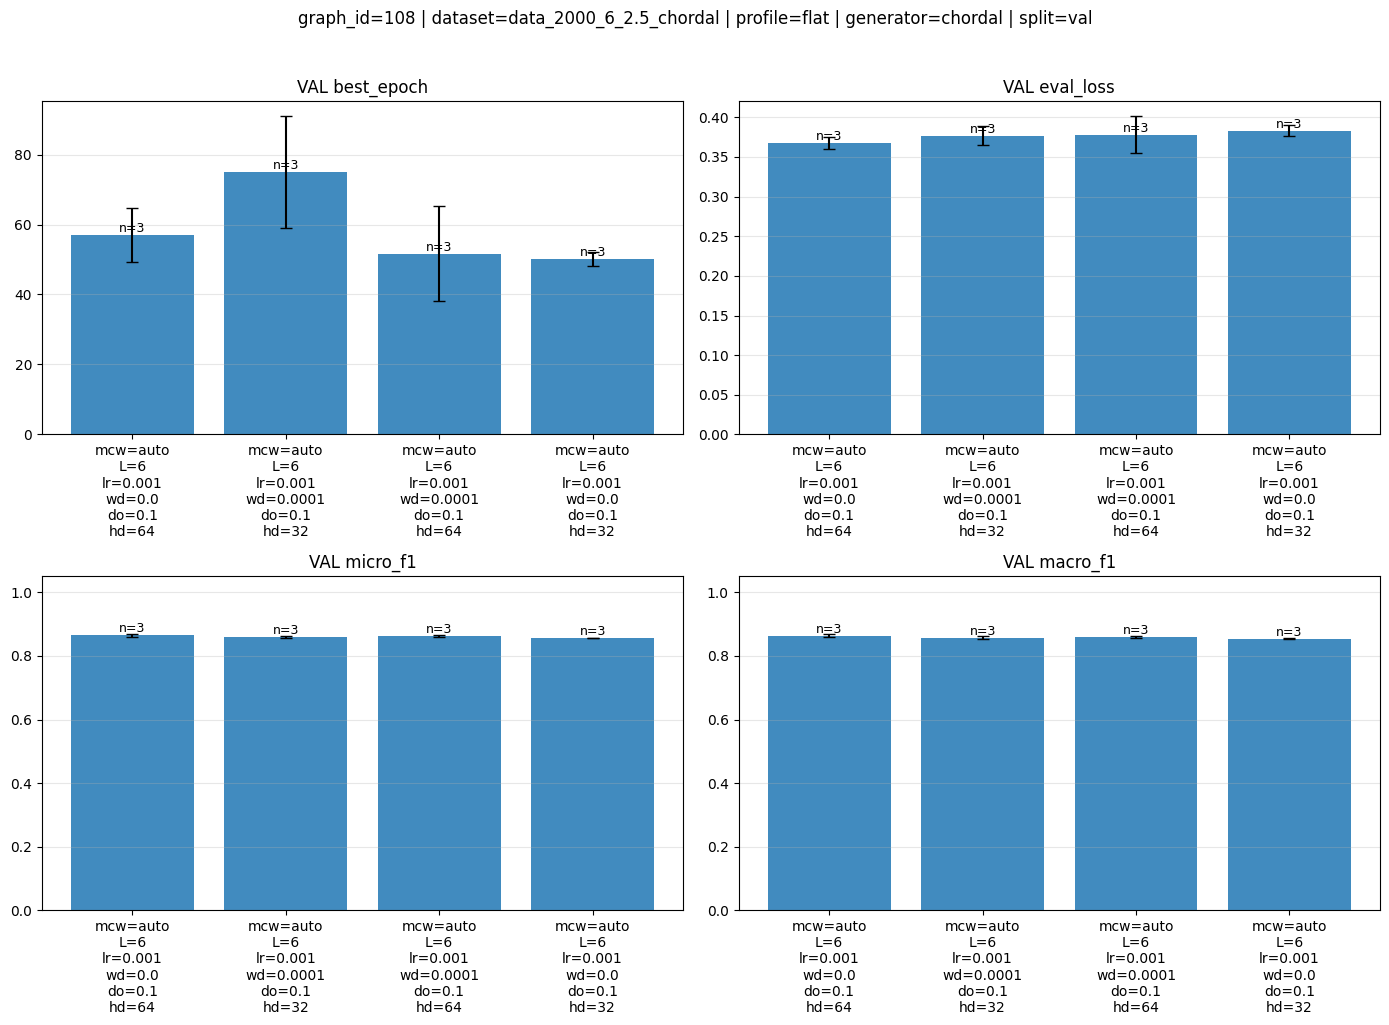

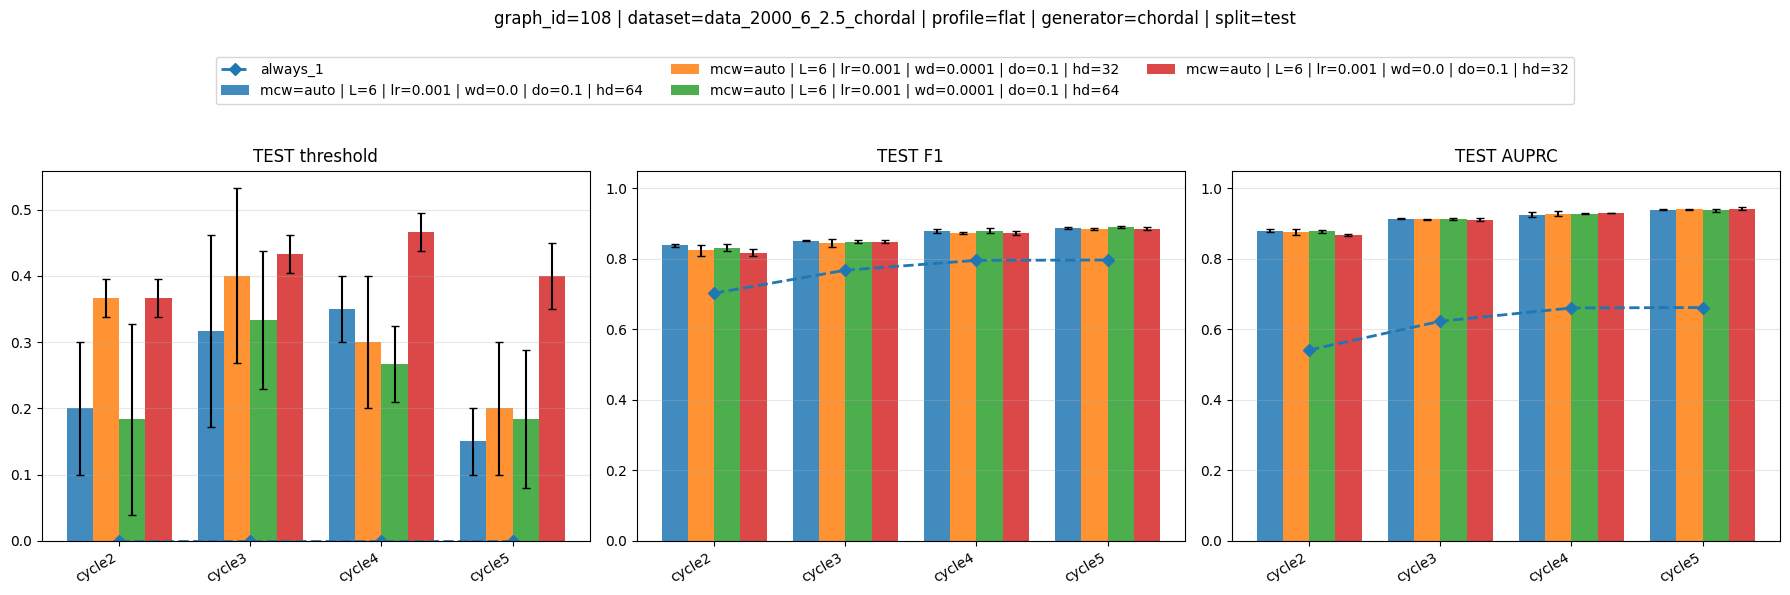

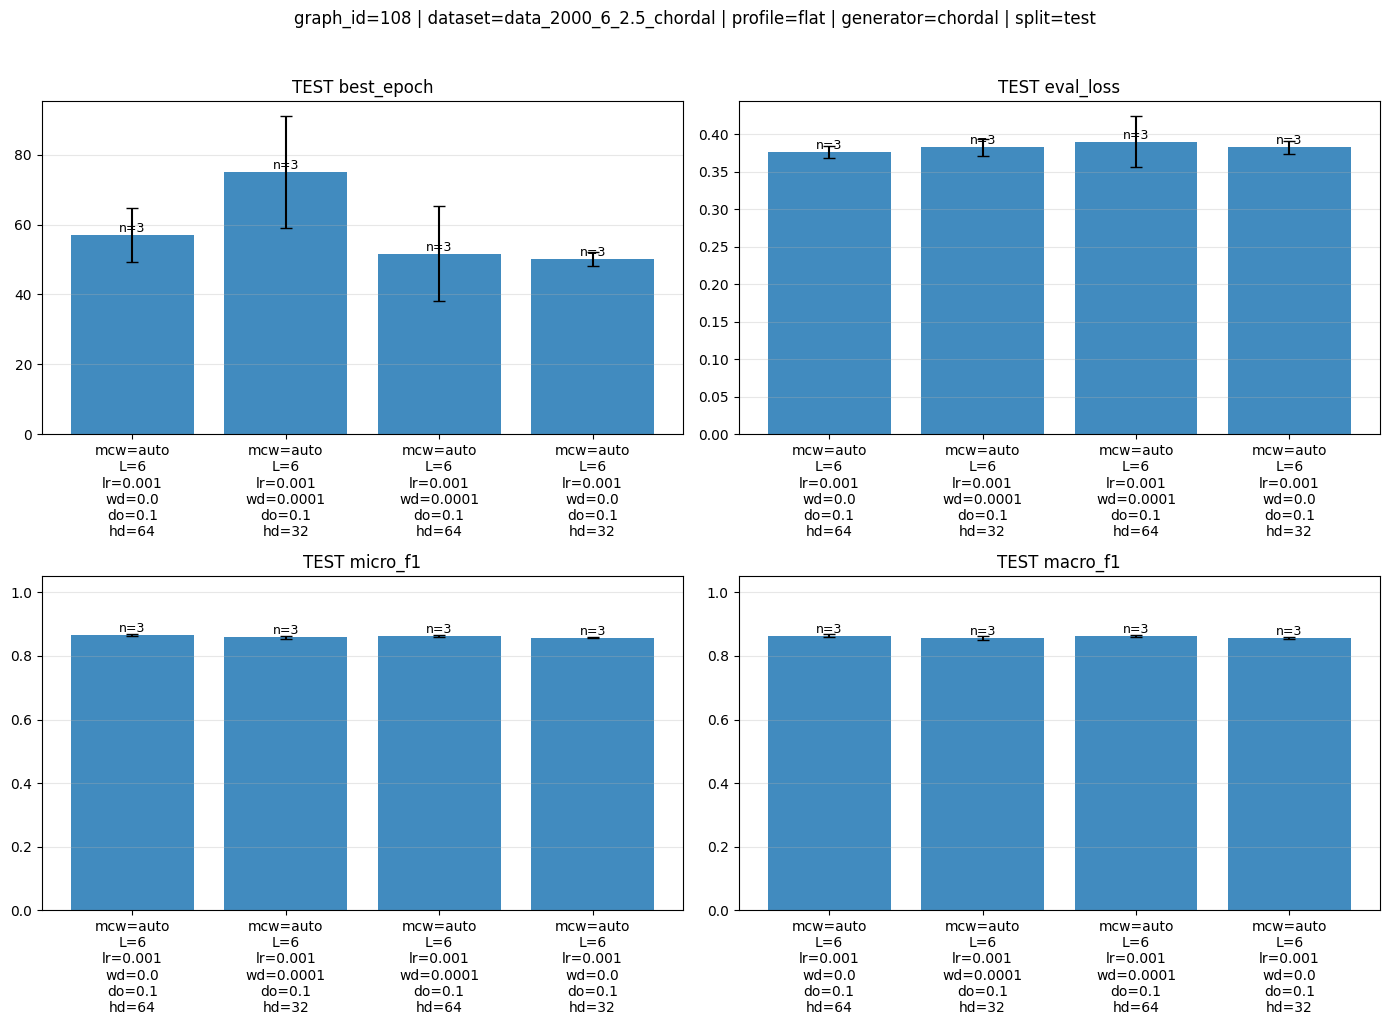


graph_id: 623
Top configs:
 - mcw=auto | L=6 | lr=0.001 | wd=0.0 | do=0.1 | hd=64
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=64
 - mcw=auto | L=6 | lr=0.001 | wd=0.0001 | do=0.1 | hd=32
 - mcw=auto | L=6 | lr=0.0005 | wd=0.0 | do=0.1 | hd=64


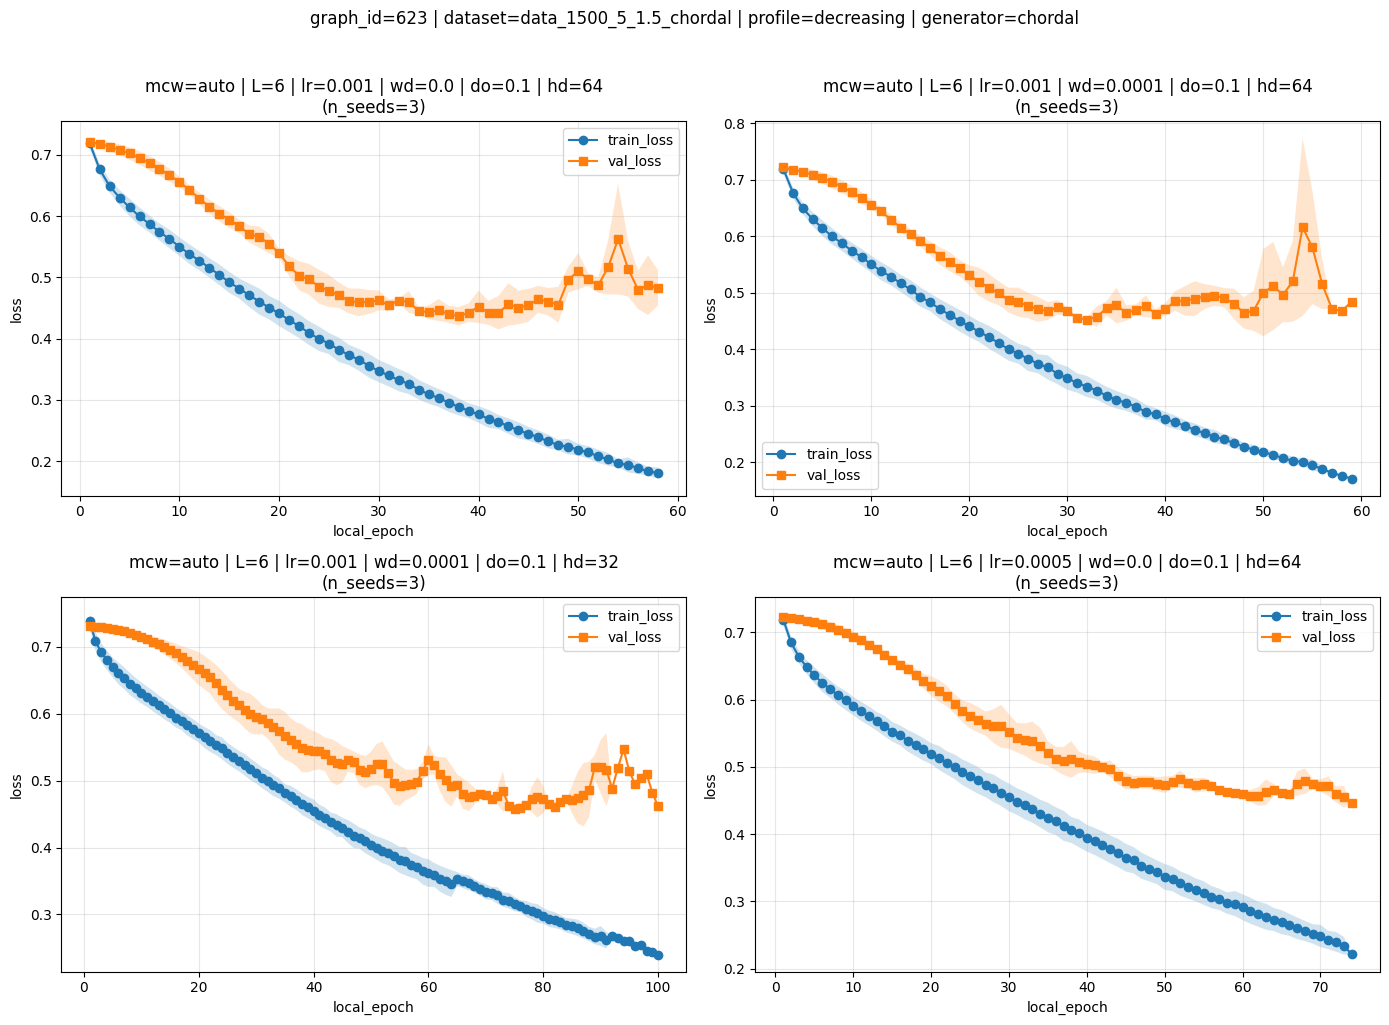

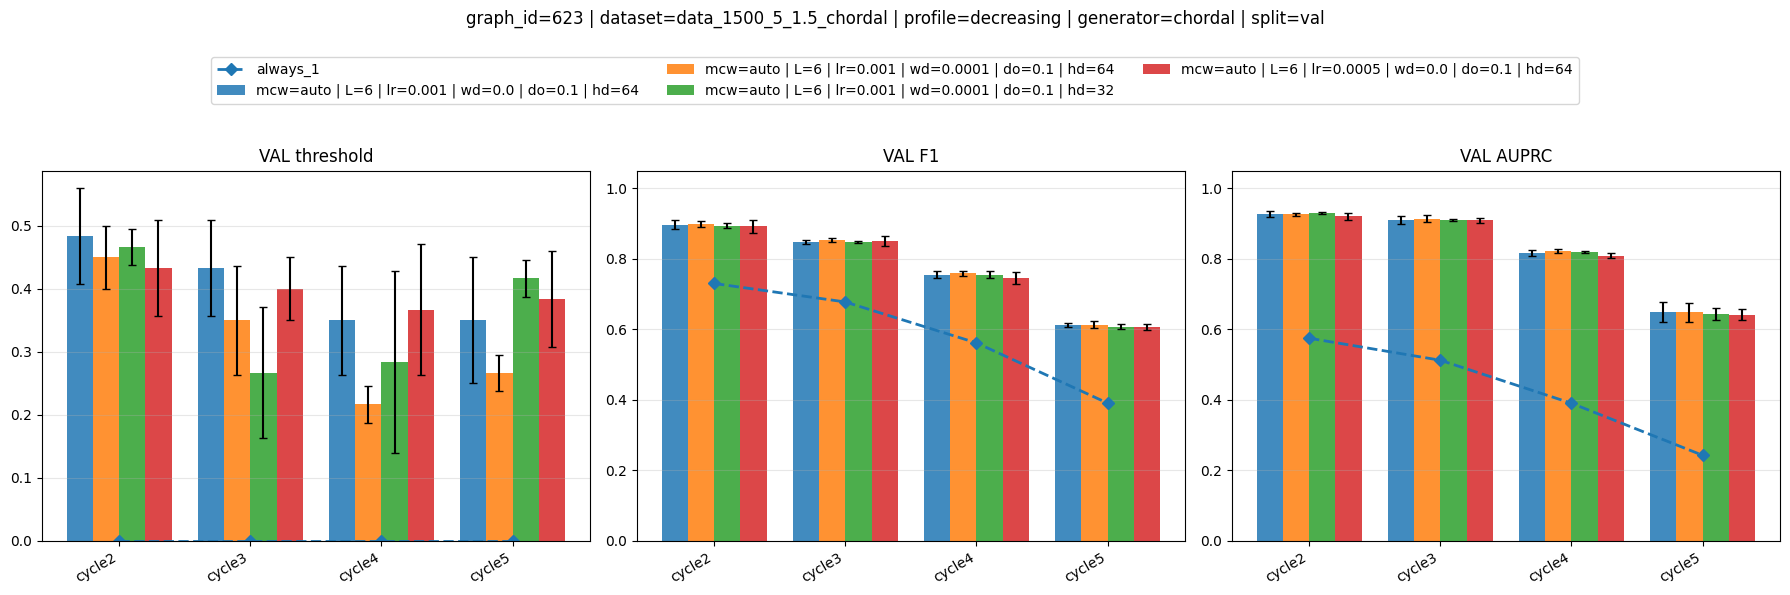

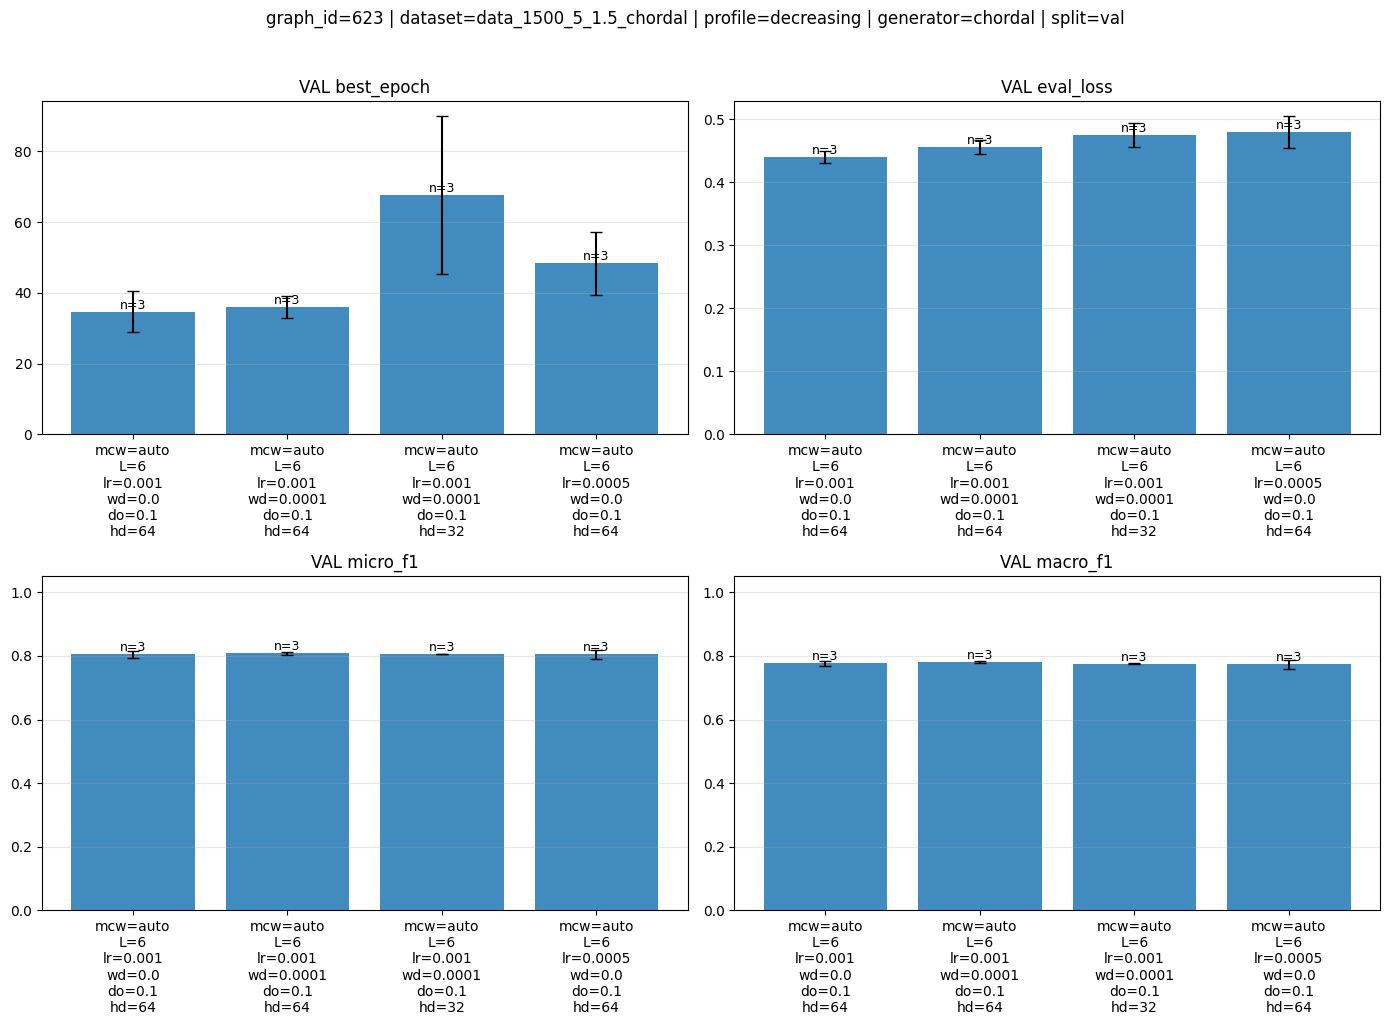

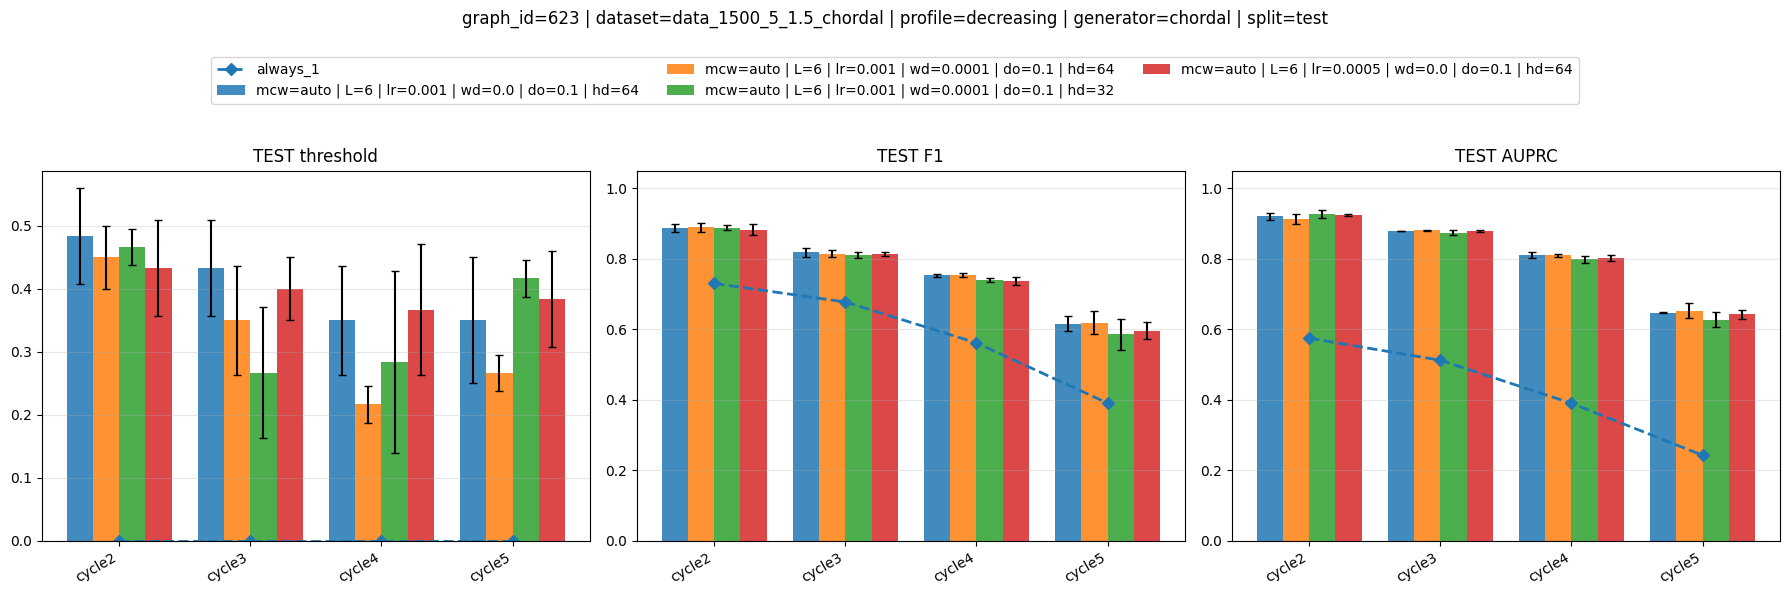

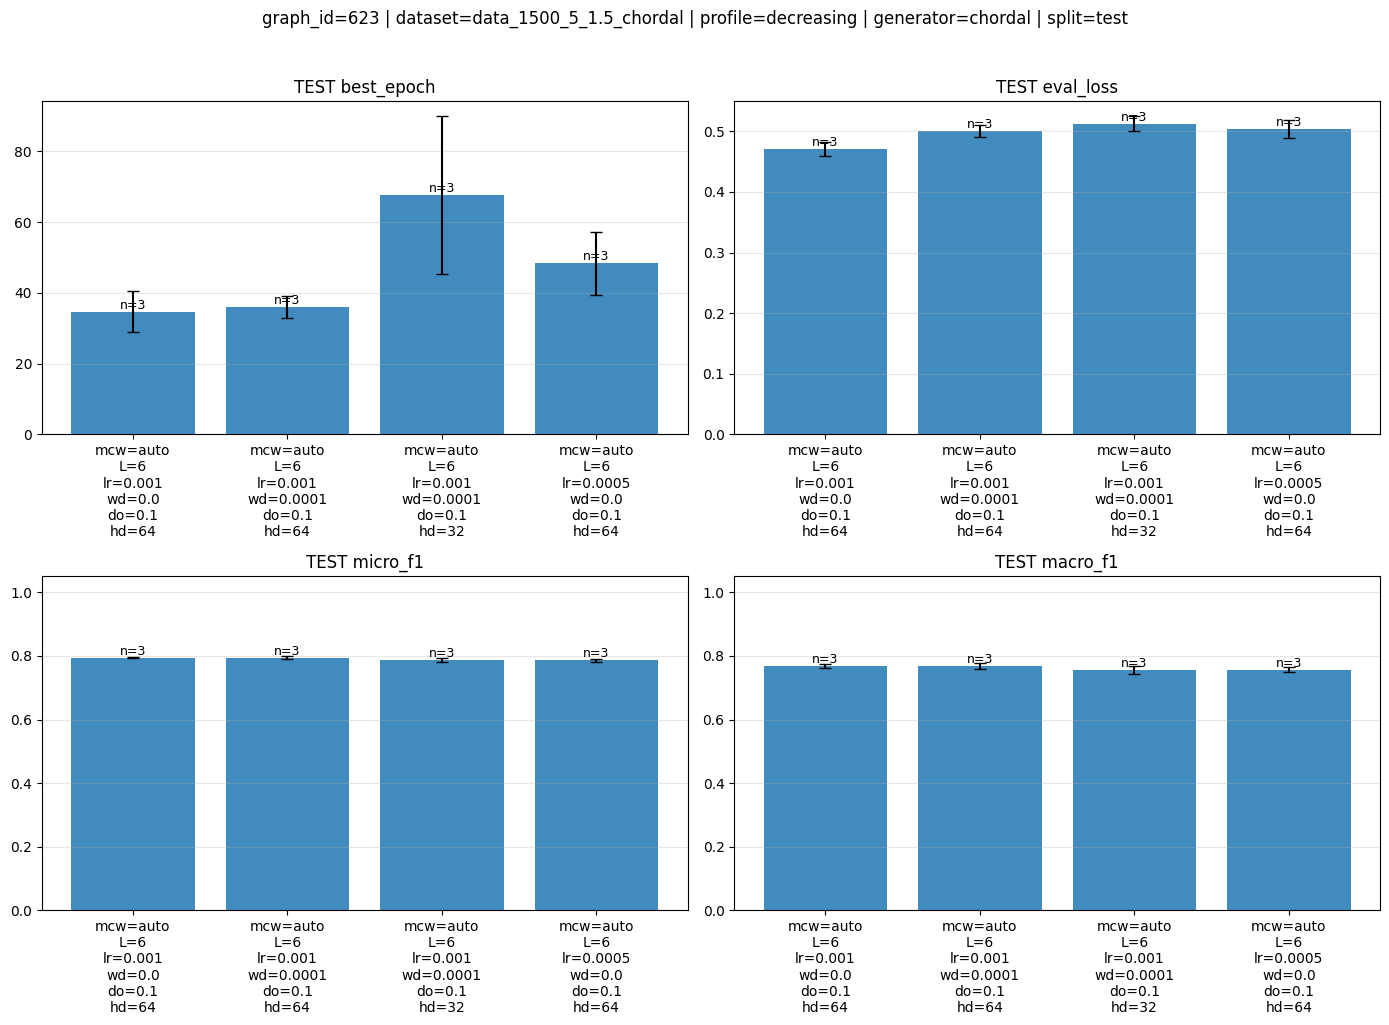


Saved loss plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_751_losses_topk.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_108_losses_topk.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_623_losses_topk.png

Saved val task metric plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_751_val_task_metrics_topk.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_108_val_task_metrics_topk.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_623_val_task_metrics_topk.png

Saved val scalar metric plots:
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_751_val_scalar_metrics_topk.png
- /Users/andreali/Documents/Subgraph_Federated_Learning/andrea/plots_experiment_topk/graph_108_val_s

In [ ]:
# ============================================================
# Top-K hyperparam selection (by val loss + gap + AUPRC/F1)
# and plotting (loss curves + per-task + scalar metrics)
#
# Paste this into a NEW notebook and run top-to-bottom.
# It assumes your experiment_test.py writes local.csv with phases:
#   - val (per-epoch train_loss/val_loss)
#   - best_val, best_val_task
#   - best_test, best_test_task
# ============================================================

import sys
import math
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

# ------------- repo root resolution (same style as yours) -------------
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# ------------- import constants from your experiment script -------------
from experiment_test import (
    TASKS,
    OUT_ROOT,
    TRAIN_SELECTED_GRAPHS_CSV_PATH,
    TRAIN_SELECTED_EXPERIMENT_LOG_PATH,
)

# ----------------------------- helpers -----------------------------
def normalize_mcw(x):
    if pd.isna(x):
        return "None"
    return str(x)

def stderr(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return 0.0
    return x.std(ddof=1) / np.sqrt(len(x))

def resolve_existing_path(path_like):
    p = Path(path_like)
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        Path("/mnt/data") / p.name,
        Path("/mnt/data") / str(p).replace("andrea/", ""),
        ROOT / str(p).replace("andrea/", ""),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    raise FileNotFoundError(f"Could not resolve path: {path_like}")

def resolve_run_dir(out_dir):
    p = Path(str(out_dir))
    candidates = [
        p,
        Path.cwd() / p,
        ROOT / p,
        ROOT / str(p).replace("andrea/", ""),
        Path("/mnt/data") / p,
        Path("/mnt/data") / str(p).replace("andrea/", ""),
    ]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    return None

def load_local_run(run_dir: Path) -> pd.DataFrame:
    local_csv = run_dir / "local.csv"
    if not local_csv.exists():
        raise FileNotFoundError(f"Missing local.csv in {run_dir}")
    return pd.read_csv(local_csv)

def aggregate_curve(curves, x_col, y_col):
    if not curves:
        return pd.DataFrame(columns=[x_col, "mean", "std", "n"])
    df = pd.concat(curves, ignore_index=True)
    out = (
        df.groupby(x_col, as_index=False)[y_col]
          .agg(mean="mean", std="std", n="count")
          .sort_values(x_col)
    )
    out["std"] = out["std"].fillna(0.0)
    return out

# Always-one baseline (optional overlay; safe if missing columns)
def always_one_metrics(pos_rate: float) -> dict:
    p = float(pos_rate)
    f1 = 0.0 if p <= 0.0 else (2.0 * p) / (1.0 + p)
    return {"threshold": 0.0, "f1": f1, "auprc": p}

def build_always_one_baseline(graph_row, split_name, task_order):
    rows = []
    for task in task_order:
        split_col = f"{split_name}_{task}_pos_rate_mean"
        generic_col = f"{task}_pos_rate_mean"
        pos_rate = graph_row.get(split_col, graph_row.get(generic_col, np.nan))
        if pd.isna(pos_rate):
            continue
        m = always_one_metrics(pos_rate)
        rows.append({"task": task, "threshold": m["threshold"], "f1": m["f1"], "auprc": m["auprc"]})
    return pd.DataFrame(rows)

# ----------------------------- load logs -----------------------------
experiment_path = resolve_existing_path(TRAIN_SELECTED_EXPERIMENT_LOG_PATH)
selected_graphs_path = resolve_existing_path(TRAIN_SELECTED_GRAPHS_CSV_PATH)

all_exp = pd.read_csv(experiment_path).copy()
train_graphs = pd.read_csv(selected_graphs_path).copy()

# normalize mcw and resolve run dirs
all_exp["mcw_norm"] = all_exp["mcw"].apply(normalize_mcw)
all_exp["run_dir"] = all_exp["out_dir"].apply(resolve_run_dir)
all_exp["run_exists"] = all_exp["run_dir"].apply(lambda x: x is not None)

print("experiment_path:", experiment_path)
print("selected_graphs_path:", selected_graphs_path)
print("num experiment rows:", len(all_exp))
print("num selected graphs:", len(train_graphs))
print("runs that exist on disk:", int(all_exp["run_exists"].sum()))

# ----------------------------- selection: Top-K configs per graph -----------------------------
# IMPORTANT: Use FULL hyperparameter key, not old mcw/layers only
HP_COLS = ["mcw_norm", "num_layers", "lr", "weight_decay", "dropout", "hidden_dim"]

def hp_key_from_row(r):
    return tuple(r[c] for c in HP_COLS)

def hp_label_from_key(key):
    d = dict(zip(HP_COLS, key))
    return (
        f"mcw={d['mcw_norm']} | L={int(d['num_layers'])} | "
        f"lr={d['lr']} | wd={d['weight_decay']} | do={d['dropout']} | hd={int(d['hidden_dim'])}"
    )

def config_label_from_row(r):
    return hp_label_from_key(hp_key_from_row(r))

# add full config label to all_exp (so plotting can filter)
all_exp["config"] = all_exp.apply(config_label_from_row, axis=1)

def summarize_one_run(exp_row):
    run_dir = exp_row["run_dir"]
    if run_dir is None:
        return None

    df = load_local_run(run_dir)

    best_val = df[df["phase"] == "best_val"]
    best_train = df[df["phase"] == "best_train"]
    best_test = df[df["phase"] == "best_test"]

    if best_val.empty or best_train.empty:
        return None

    best_val = best_val.iloc[-1]
    best_train = best_train.iloc[-1]
    best_test = best_test.iloc[-1] if not best_test.empty else None

    best_epoch = int(best_val.get("best_epoch", -1))
    stopped_epoch = int(df[df["phase"] == "val"]["local_epoch"].max()) if (df["phase"] == "val").any() else -1

    out = {
        "graph_id": exp_row["graph_id"],
        "seed": exp_row["seed"],
        **{c: exp_row[c] for c in HP_COLS},
        "config": exp_row["config"],
        "out_dir": exp_row["out_dir"],
        "run_dir": str(run_dir),
        "best_epoch": best_epoch,
        "stopped_epoch": stopped_epoch,
        # Use the values you already log
        "best_val_mean_auprc": float(best_val.get("best_val_mean_auprc", np.nan)),
        "best_val_mean_f1": float(best_val.get("best_val_mean_f1", np.nan)),
        "best_train_eval_loss": float(best_train.get("eval_loss", np.nan)),
        "best_val_eval_loss": float(best_val.get("eval_loss", np.nan)),
    }
    out["gap_eval_loss"] = out["best_val_eval_loss"] - out["best_train_eval_loss"]

    if best_test is not None:
        out["best_test_eval_loss"] = float(best_test.get("eval_loss", np.nan))
        out["best_test_macro_f1"] = float(best_test.get("macro_f1", np.nan))

    return out

# Build run-level summary
rows = []
for _, r in all_exp[all_exp["run_exists"]].iterrows():
    s = summarize_one_run(r)
    if s is not None:
        rows.append(s)

run_summary = pd.DataFrame(rows)
print("Runs with local.csv parsed:", len(run_summary))

# Aggregate by (graph_id + HP) across seeds
group_cols = ["graph_id"] + HP_COLS
hp_summary = (
    run_summary
    .groupby(group_cols, as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        val_loss_mean=("best_val_eval_loss", "mean"),
        val_loss_stderr=("best_val_eval_loss", stderr),
        gap_mean=("gap_eval_loss", "mean"),
        gap_stderr=("gap_eval_loss", stderr),
        auprc_mean=("best_val_mean_auprc", "mean"),
        auprc_stderr=("best_val_mean_auprc", stderr),
        f1_mean=("best_val_mean_f1", "mean"),
        f1_stderr=("best_val_mean_f1", stderr),
        stopped_epoch_mean=("stopped_epoch", "mean"),
    )
)

# Require full seeds (prevents "lucky single run" configs)
REQUIRED_SEEDS = int(all_exp["seed"].nunique())
hp_summary_full = hp_summary[hp_summary["n_seeds"] == REQUIRED_SEEDS].copy()

# Rank configs: low val_loss, low gap, high auprc, high f1
hp_summary_full = hp_summary_full.sort_values(
    ["graph_id", "val_loss_mean", "gap_mean", "auprc_mean", "f1_mean"],
    ascending=[True, True, True, False, False],
)

TOPK = 4
topk_hp = hp_summary_full.groupby("graph_id").head(TOPK).copy()

print("\nTopK configs per graph (aggregated over seeds):")
display(
    topk_hp[["graph_id","n_seeds","val_loss_mean","gap_mean","auprc_mean","f1_mean","stopped_epoch_mean"] + HP_COLS]
)

def top_configs_for_graph(graph_id):
    rows = topk_hp[topk_hp["graph_id"] == graph_id].copy()
    # Convert hp row -> config label
    return rows.apply(lambda r: hp_label_from_key(tuple(r[c] for c in HP_COLS)), axis=1).tolist()

# ----------------------------- plotting: loss + best split metrics -----------------------------
def collect_graph_runs(graph_id):
    runs = all_exp[all_exp["graph_id"] == graph_id].copy()
    runs["run_dir"] = runs["out_dir"].apply(resolve_run_dir)
    runs["run_exists"] = runs["run_dir"].apply(lambda x: x is not None)
    return runs

def summarize_best_split(graph_runs, split_name):
    scalar_rows = []
    task_rows = []
    scalar_phase = f"best_{split_name}"
    task_phase = f"best_{split_name}_task"

    for _, run in graph_runs.iterrows():
        run_dir = run["run_dir"]
        if run_dir is None:
            continue

        local_df = load_local_run(run_dir)

        scalar_part = local_df[local_df["phase"] == scalar_phase].copy()
        if not scalar_part.empty:
            row = scalar_part.iloc[-1].to_dict()
            row.update({
                "graph_id": run["graph_id"],
                "config": run["config"],
                "seed": run["seed"],
                "run_dir": str(run_dir),
                "split": split_name,
            })
            scalar_rows.append(row)

        task_part = local_df[local_df["phase"] == task_phase].copy()
        if not task_part.empty:
            task_part = task_part.assign(
                graph_id=run["graph_id"],
                config=run["config"],
                seed=run["seed"],
                run_dir=str(run_dir),
                split=split_name,
            )
            task_rows.append(task_part)

    scalar_df = pd.DataFrame(scalar_rows)
    task_df = pd.concat(task_rows, ignore_index=True) if task_rows else pd.DataFrame()
    return scalar_df, task_df

def make_loss_figure_for_graph(graph_row, graph_runs, save_root, configs):
    n = len(configs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), squeeze=False)
    axes = axes.flatten()

    for ax, config in zip(axes, configs):
        cfg_runs = graph_runs[graph_runs["config"] == config].copy()

        train_curves, val_curves = [], []
        for _, run in cfg_runs.iterrows():
            run_dir = run["run_dir"]
            if run_dir is None:
                continue
            local_df = load_local_run(run_dir)
            val_df = local_df[local_df["phase"] == "val"].copy()
            if val_df.empty:
                continue
            val_df = val_df.sort_values("local_epoch")
            train_curves.append(val_df[["local_epoch", "train_loss"]].assign(seed=run["seed"]))
            val_curves.append(val_df[["local_epoch", "val_loss"]].assign(seed=run["seed"]))

        train_agg = aggregate_curve(train_curves, "local_epoch", "train_loss")
        val_agg = aggregate_curve(val_curves, "local_epoch", "val_loss")

        if not train_agg.empty:
            x = train_agg["local_epoch"].to_numpy(dtype=float)
            m = train_agg["mean"].to_numpy(dtype=float)
            s = train_agg["std"].to_numpy(dtype=float)
            ax.plot(x, m, marker="o", label="train_loss")
            ax.fill_between(x, m - s, m + s, alpha=0.2)

        if not val_agg.empty:
            x = val_agg["local_epoch"].to_numpy(dtype=float)
            m = val_agg["mean"].to_numpy(dtype=float)
            s = val_agg["std"].to_numpy(dtype=float)
            ax.plot(x, m, marker="s", label="val_loss")
            ax.fill_between(x, m - s, m + s, alpha=0.2)

        n_seeds = int(cfg_runs["seed"].nunique()) if len(cfg_runs) else 0
        ax.set_title(f"{config}\n(n_seeds={n_seeds})")
        ax.set_xlabel("local_epoch")
        ax.set_ylabel("loss")
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend()

    # hide extra axes
    for j in range(len(configs), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row.get('dataset_id','NA')} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')}",
        y=1.02,
    )
    fig.tight_layout()

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_losses_topk.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path

def aggregate_task_metric(task_df, metric_col):
    if task_df.empty:
        return pd.DataFrame(columns=["config", "task", "mean", "std", "n"])
    out = (
        task_df.groupby(["config", "task"], as_index=False)[metric_col]
               .agg(mean="mean", std="std", n="count")
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def make_task_metric_figure_for_graph(graph_row, task_df, save_root, split_name, configs):
    # 3 panels: threshold / f1 / auprc
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)
    axes = axes.flatten()

    metric_specs = [
        ("threshold", f"{split_name.upper()} threshold"),
        ("f1", f"{split_name.upper()} F1"),
        ("auprc", f"{split_name.upper()} AUPRC"),
    ]

    task_order = list(TASKS)
    x = np.arange(len(task_order), dtype=float)
    width = 0.8 / max(1, len(configs))  # auto fit

    dummy_df = build_always_one_baseline(graph_row, split_name, task_order)

    for ax, (metric_col, title) in zip(axes, metric_specs):
        agg = aggregate_task_metric(task_df, metric_col)
        if agg.empty:
            ax.set_title(f"{title} (no data)")
            ax.axis("off")
            continue

        for i, config in enumerate(configs):
            sub = agg[agg["config"] == config].copy()
            sub["task"] = pd.Categorical(sub["task"], categories=task_order, ordered=True)
            sub = sub.sort_values("task")

            means = [np.nan] * len(task_order)
            stds = [0.0] * len(task_order)
            for j, task in enumerate(task_order):
                row = sub[sub["task"] == task]
                if not row.empty:
                    means[j] = float(row["mean"].iloc[0])
                    stds[j] = float(row["std"].iloc[0])

            xpos = x - 0.4 + (i + 0.5) * width
            ax.bar(xpos, means, width=width, label=config, yerr=stds, capsize=3, alpha=0.85)

        # overlay always_1 baseline
        if not dummy_df.empty and metric_col in dummy_df.columns:
            dummy_sub = dummy_df.set_index("task").reindex(task_order)
            dummy_vals = dummy_sub[metric_col].to_numpy(dtype=float)
            ax.plot(x, dummy_vals, linestyle="--", marker="D", linewidth=2, label="always_1")

        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(task_order, rotation=30, ha="right")
        ax.grid(axis="y", alpha=0.3)
        if metric_col in {"f1", "auprc"}:
            ax.set_ylim(0, 1.05)
        elif metric_col == "threshold":
            ax.set_ylim(bottom=0)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.10))

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row.get('dataset_id','NA')} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')} | split={split_name}",
        y=1.18,
    )
    fig.tight_layout()

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_task_metrics_topk.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path

def aggregate_scalar_metric(scalar_df, metric_col):
    if scalar_df.empty:
        return pd.DataFrame(columns=["config", "mean", "std", "n"])
    out = (
        scalar_df.groupby("config", as_index=False)[metric_col]
                 .agg(mean="mean", std="std", n="count")
    )
    out["std"] = out["std"].fillna(0.0)
    return out

def make_scalar_metric_figure_for_graph(graph_row, scalar_df, save_root, split_name, configs):
    n = len(configs)
    ncols = 2
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10), squeeze=False)
    axes = axes.flatten()

    metric_specs = [
        ("best_epoch", f"{split_name.upper()} best_epoch"),
        ("eval_loss", f"{split_name.upper()} eval_loss"),
        ("micro_f1", f"{split_name.upper()} micro_f1"),
        ("macro_f1", f"{split_name.upper()} macro_f1"),
    ]

    x = np.arange(n, dtype=float)

    for ax, (metric_col, title) in zip(axes, metric_specs):
        if metric_col not in scalar_df.columns:
            ax.set_title(f"{title} (missing col)")
            ax.axis("off")
            continue

        agg = aggregate_scalar_metric(scalar_df, metric_col)
        if agg.empty:
            ax.set_title(f"{title} (no data)")
            ax.axis("off")
            continue

        means, stds, ns = [], [], []
        for config in configs:
            row = agg[agg["config"] == config]
            if row.empty:
                means.append(np.nan); stds.append(0.0); ns.append(0)
            else:
                means.append(float(row["mean"].iloc[0]))
                stds.append(float(row["std"].iloc[0]))
                ns.append(int(row["n"].iloc[0]))

        ax.bar(x, means, yerr=stds, capsize=4, alpha=0.85)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace(" | ", "\n") for c in configs], rotation=0)
        ax.grid(axis="y", alpha=0.3)

        if metric_col in {"micro_f1", "macro_f1"}:
            ax.set_ylim(0, 1)
        elif metric_col == "eval_loss":
            ax.set_ylim(0,1)

        # annotate n
        for xi, m, n_ in zip(x, means, ns):
            if pd.notna(m):
                ax.text(xi, m, f"n={n_}", ha="center", va="bottom", fontsize=9)

    fig.suptitle(
        f"graph_id={graph_row['graph_id']} | dataset={graph_row.get('dataset_id','NA')} | "
        f"profile={graph_row.get('selected_profile', 'NA')} | generator={graph_row.get('type', 'NA')} | split={split_name}",
        y=1.02,
    )
    fig.tight_layout()

    save_root.mkdir(parents=True, exist_ok=True)
    save_path = save_root / f"graph_{int(graph_row['graph_id'])}_{split_name}_scalar_metrics_topk.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    return save_path

# ----------------------------- run plotting for all selected graphs -----------------------------
PLOTS_ROOT = Path.cwd() / "plots_experiment_topk"
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

saved_loss_plots = []
saved_val_task_plots = []
saved_val_scalar_plots = []
saved_test_task_plots = []
saved_test_scalar_plots = []

for _, selected in train_graphs.iterrows():
    graph_id = selected["graph_id"]
    print("\n" + "=" * 110)
    print("graph_id:", graph_id)

    graph_runs = collect_graph_runs(graph_id)
    if graph_runs["run_exists"].sum() == 0:
        print("No run directories found for this graph.")
        continue

    configs = top_configs_for_graph(graph_id)
    if not configs:
        print("No TOPK configs available (did all seeds finish?)")
        continue

    # keep only runs belonging to Top-K configs
    graph_runs = graph_runs[graph_runs["config"].isin(configs)].copy()
    print("Top configs:")
    for c in configs:
        print(" -", c)

    # loss curves
    loss_plot_path = make_loss_figure_for_graph(selected, graph_runs, PLOTS_ROOT, configs=configs)
    saved_loss_plots.append(loss_plot_path)

    # val / test task + scalar metrics
    for split_name, task_store, scalar_store in [
        ("val", saved_val_task_plots, saved_val_scalar_plots),
        ("test", saved_test_task_plots, saved_test_scalar_plots),
    ]:
        scalar_df, task_df = summarize_best_split(graph_runs, split_name)

        # (optional) restrict to configs order and drop anything else
        if not scalar_df.empty:
            scalar_df = scalar_df[scalar_df["config"].isin(configs)].copy()
        if not task_df.empty:
            task_df = task_df[task_df["config"].isin(configs)].copy()

        if not task_df.empty:
            task_plot_path = make_task_metric_figure_for_graph(selected, task_df, PLOTS_ROOT, split_name, configs=configs)
            task_store.append(task_plot_path)
        else:
            print(f"No best_{split_name}_task rows found.")

        if not scalar_df.empty:
            scalar_plot_path = make_scalar_metric_figure_for_graph(selected, scalar_df, PLOTS_ROOT, split_name, configs=configs)
            scalar_store.append(scalar_plot_path)
        else:
            print(f"No best_{split_name} rows found.")

print("\nSaved loss plots:")
for p in saved_loss_plots:
    print("-", p)

print("\nSaved val task metric plots:")
for p in saved_val_task_plots:
    print("-", p)

print("\nSaved val scalar metric plots:")
for p in saved_val_scalar_plots:
    print("-", p)

print("\nSaved test task metric plots:")
for p in saved_test_task_plots:
    print("-", p)

print("\nSaved test scalar metric plots:")
for p in saved_test_scalar_plots:
    print("-", p)